# Business Impact Analysis

## Findings

- The improved forecast from the LightGBM model reduces the estimated error cost by $1,705,506 over the test window when compared to the seasonal naive model. 
- Beverages, grocery and produce dominate the cost ranking, which is likely due to their volume since their per-unit error is low. Forecasting efforts should focus on these top categories for the biggest cost saving wins.
- The model leans toward underforecasting for both perishable and non-perishable families, so a planner should bias safety stock upward. 
- NOTE: These assumption parameters are illustrative, and in production would be switched out for a company's actual cost parameters.

## Imports

In [1]:
import sys; sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
lgbm_preds = pd.read_csv("../outputs/results/lgbm_predictions.csv")
naive_preds = pd.read_csv("../outputs/results/seasonal_naive_predictions.csv")

## Assumptions

In [3]:
ASSUMPTIONS = {
    "avg_unit_margin": 1.50,        # $ profit per unit sold
    "holding_cost_per_unit": 0.20,  # $ to hold one excess non-parishable unit over the period
    "waste_cost_per_unit": 1.00,    # $ lost per spoiled perishable unit (~ the cost of the goods)
    "stockout_goodwill": 0.0        # optional extra penalty for lost customer goodwill 
}

PERISHABLE = ["PRODUCE", "DAIRY", "MEATS", "POULTRY", "SEAFOOD", "DELI", "BREAD/BAKERY", "EGGS", "FROZEN FOODS", "PREPARED FOODS"]

## Cost Function

In [4]:
def cost_error(row, a=ASSUMPTIONS):
    error = row["y_pred"] - row["y_true"]

    # Estimate error for over-stock
    if error > 0: 
        if row["family"] in PERISHABLE:
            return error * a["waste_cost_per_unit"]
        else:
            return error * a["holding_cost_per_unit"]
    
    # Estimate error for understock
    else:
        return abs(error) * (a["avg_unit_margin"] + a["stockout_goodwill"])

### Calculate total cost based on predictions

In [5]:
def total_cost(preds, label):
    preds = preds.copy()
    preds["cost"] = preds.apply(cost_error, axis=1)

    return preds, preds["cost"].sum()

lgbm_priced, lgbm_cost = total_cost(lgbm_preds, "lightgbm")
naive_priced, naive_cost = total_cost(naive_preds, "seasonal_naive")

print(f"Seasonal-naive forecast error cost: ${naive_cost:,.0f}")
print(f"LightGBM forecast error cost: ${lgbm_cost:,.0f}")
print(f"Savings from better forecasting: ${naive_cost - lgbm_cost:,.0f}")

Seasonal-naive forecast error cost: $8,946,739
LightGBM forecast error cost: $7,241,233
Savings from better forecasting: $1,705,506


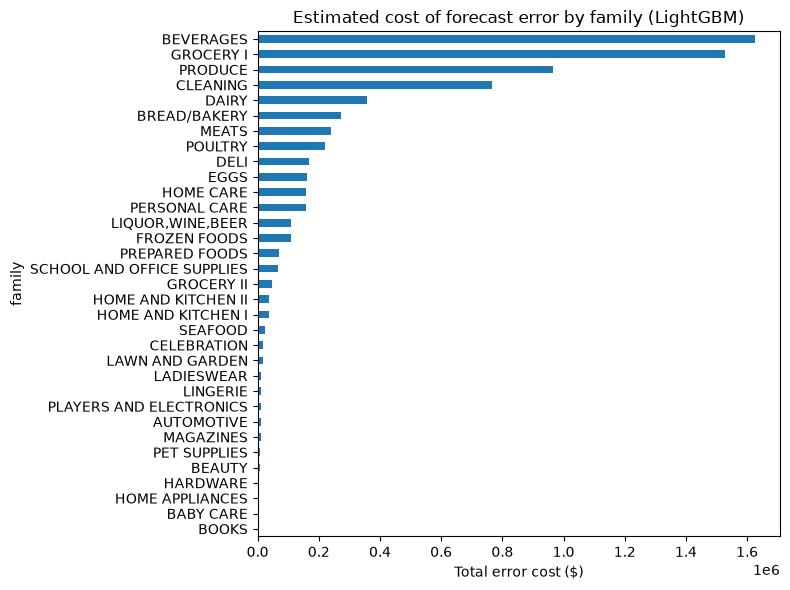

<Figure size 640x480 with 0 Axes>

In [6]:
by_family_cost = (lgbm_priced.groupby("family", observed=True)["cost"].sum().sort_values(ascending=False))

by_family_cost.plot(kind="barh", figsize=(8,6), title="Estimated cost of forecast error by family (LightGBM)")
plt.xlabel("Total error cost ($)")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

plt.savefig("../outputs/figures/cost_by_family.png", dpi=150, bbox_inches="tight")

### Analyze over versus under forecasting

In [7]:
lgbm_priced["direction"] = np.where(lgbm_priced.y_pred > lgbm_priced.y_true, "over", "under")
lgbm_priced["perishable"] = lgbm_priced.family.isin(PERISHABLE)
summary = lgbm_priced.groupby(["perishable", "direction"])["cost"].sum().unstack()
print(summary.round(0))

direction        over      under
perishable                      
False        437164.0  4213542.0
True        1161650.0  1428878.0


## Dashboard export

In [8]:
stores = pd.read_parquet("../data/processed/stores.parquet")

In [9]:
dashboard = lgbm_priced.copy()
dashboard["error"] = dashboard["y_pred"] - dashboard["y_true"]
dashboard["abs_error"] = dashboard["error"].abs()
dashboard = dashboard.rename(columns={"y_true": "actual", "y_pred": "forecast"})

dashboard = dashboard.merge(
    stores[["store_nbr", "city", "state", "type", "cluster"]],
    on="store_nbr", how="left"
)

cols = ["date", "store_nbr", "city", "state", "family", "perishable", "actual", "forecast", "error", "abs_error", "cost"]
dashboard = dashboard[cols].sort_values(["date", "store_nbr", "family"])

dashboard.to_csv("../outputs/results/dashboard_data.csv", index=False)
print(f"Exported {len(dashboard)} rows, {dashboard.date.nunique()} dates.")

Exported 114048 rows, 64 dates.
